In [8]:
!pip install earthengine-api geemap pandas matplotlib seaborn osmnx geopandas scikit-learn shapely openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.1/477.1 kB 10.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 20.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 18.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00a 0:00

In [ ]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Trigger the authentication flow. This will open a new tab to log in to your Google account.
# You only need to do this once.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-uhi-project') # Replace with your GCP project ID if required, or just ee.Initialize()

In [ ]:
import ee
import os
import pandas as pd
import numpy as np
import osmnx as ox
import geopandas as gpd

# File paths for our checkpoints
gee_file = 'bengaluru_gee_features.csv'
osmnx_file = 'bengaluru_morphology_features.csv'

# Shrinking the ROI to Central Bengaluru to prevent OSMnx kernel crashes
# [West, South, East, North]
lon_min, lat_min, lon_max, lat_max = 77.55, 12.90, 77.65, 13.00
gee_roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])

# ==========================================
# STEP 1: GOOGLE EARTH ENGINE DATA
# ==========================================
if os.path.exists(gee_file):
    print(f"Loading GEE data from {gee_file}...")
    df_gee = pd.read_csv(gee_file)
else:
    print("Pulling GEE data from Google's servers. This takes ~30 seconds...")
    ee.Initialize(project='ee-uhi-project') # Assuming your project is registered
    
    # 1. Multispectral & Target Variable
    def prep_landsat(image):
        qa = image.select('QA_PIXEL')
        mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
        lst = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
        ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
        ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
        mndwi = image.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')
        # EVI and SAVI
        evi = image.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('SR_B5'), 'RED': image.select('SR_B4'), 'BLUE': image.select('SR_B2')
        }).rename('EVI')
        savi = image.expression('((NIR - RED) / (NIR + RED + 0.5)) * (1.5)', {
            'NIR': image.select('SR_B5'), 'RED': image.select('SR_B4')
        }).rename('SAVI')
        return image.updateMask(mask).addBands([lst, ndvi, ndbi, mndwi, evi, savi])

    l8_data = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').map(prep_landsat).median()

    # 2. Climate & Human Activity
    era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').median()
    wind_speed = era5.select('u_component_of_wind_10m').pow(2).add(era5.select('v_component_of_wind_10m').pow(2)).sqrt().rename('Wind_Speed')
    temp_air = era5.select('temperature_2m')
    temp_dew = era5.select('dewpoint_temperature_2m')
    rh = ee.Image(100).subtract(ee.Image(5).multiply(temp_air.subtract(temp_dew))).rename('Relative_Humidity')
    
    pop_density = ee.ImageCollection("WorldPop/GP/100m/pop").filterBounds(gee_roi).median().rename('Pop_Density')
    no2 = ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2").filterBounds(gee_roi).filterDate('2023-03-01', '2023-05-31').median().select('NO2_column_number_density').rename('NO2_Emissions')

    # 3. Stack and Sample
    master_image = ee.Image([l8_data.select(['LST', 'NDVI', 'NDBI', 'MNDWI', 'EVI', 'SAVI']), wind_speed, rh, pop_density, no2])
    sample_grid = master_image.sample(region=gee_roi, scale=100, numPixels=2500, geometries=True)

    # 4. Convert to DataFrame and Save
    features = sample_grid.getInfo()['features']
    df_gee = pd.DataFrame([f['properties'] for f in features])
    df_gee['Longitude'] = [f['geometry']['coordinates'][0] for f in features]
    df_gee['Latitude'] = [f['geometry']['coordinates'][1] for f in features]
    
    df_gee.to_csv(gee_file, index=False)
    print(f"Saved GEE data to {gee_file}!")

# ==========================================
# STEP 2: OPENSTREETMAP MORPHOLOGY DATA
# ==========================================
import numpy as np
import shapely.wkt

if os.path.exists(osmnx_file):
    print(f"Loading Morphology data from {osmnx_file}...")
    buildings_df = pd.read_csv(osmnx_file)
    # Convert the text back into spatial polygons
    buildings_df['geometry'] = buildings_df['geometry_wkt'].apply(shapely.wkt.loads)
    buildings_proj = gpd.GeoDataFrame(buildings_df, geometry='geometry', crs="EPSG:32643")
else:
    print("Pulling OSM Morphology data. Because we shrank the ROI, this should take ~2 to 4 minutes...")
    
    bbox = (lon_min, lat_min, lon_max, lat_max) 
    tags = {'building': True}
    
    # Pull the vector data
    buildings = ox.features_from_bbox(bbox=bbox, tags=tags)    
    
    # Extract raw height and levels
    buildings['height_raw'] = pd.to_numeric(buildings.get('height', pd.Series(dtype=float)), errors='coerce')
    
    if 'building:levels' in buildings.columns:
        buildings['levels'] = pd.to_numeric(buildings['building:levels'], errors='coerce')
    else:
        buildings['levels'] = np.nan
    
    # Project to calculate precise area in square meters
    buildings_proj = buildings.to_crs(epsg=32643)
    buildings_proj['bldg_area'] = buildings_proj.geometry.area
    
    # The Strict Extraction Function (No Heuristics)
    def extract_strict_height(row):
        if pd.notna(row['height_raw']):
            return row['height_raw']
        elif pd.notna(row['levels']):
            return row['levels'] * 3.0 
        else:
            return np.nan
    
    # Apply the strict function
    buildings_proj['height'] = buildings_proj.apply(extract_strict_height, axis=1)
    
    # Calculate volume ONLY for buildings where we know the height
    buildings_proj['bldg_volume'] = buildings_proj['bldg_area'] * buildings_proj['height']
    
    # Convert geometry to text so it can be safely saved in a CSV
    buildings_proj['geometry_wkt'] = buildings_proj.geometry.apply(lambda x: x.wkt)
    
    # Keep only the features we need to save disk space
    cols_to_keep = ['height', 'bldg_area', 'bldg_volume', 'geometry_wkt']
    buildings_df = pd.DataFrame(buildings_proj[cols_to_keep])
    
    buildings_df.to_csv(osmnx_file, index=False)
    print(f"Saved Morphology data to {osmnx_file}!")

print("\n--- Both datasets are ready in your environment! ---")

In [ ]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np

print("Starting the Spatial Merge with Strict Height Extraction...")

# 1. Load the GEE points and convert to a spatial format
df_gee = pd.read_csv('bengaluru_gee_features.csv')
gdf_gee = gpd.GeoDataFrame(
    df_gee, 
    geometry=gpd.points_from_xy(df_gee.Longitude, df_gee.Latitude),
    crs="EPSG:4326"
)

# Project to meters (UTM Zone 43N for Bengaluru)
gdf_gee_proj = gdf_gee.to_crs(epsg=32643)

# Create a 50-meter radius buffer around each point (representing our ~100m grid cell)
gdf_gee_proj['geometry'] = gdf_gee_proj.geometry.buffer(50)

# 2. Re-pull the Buildings and Apply Strict Height Logic
bbox = (77.55, 12.90, 77.65, 13.00) 
buildings = ox.features_from_bbox(bbox=bbox, tags={'building': True})

buildings['height_raw'] = pd.to_numeric(buildings.get('height', pd.Series(dtype=float)), errors='coerce')
if 'building:levels' in buildings.columns:
    buildings['levels'] = pd.to_numeric(buildings['building:levels'], errors='coerce')
else:
    buildings['levels'] = np.nan

buildings_proj = buildings.to_crs(epsg=32643)
buildings_proj['bldg_area'] = buildings_proj.geometry.area

def extract_strict_height(row):
    if pd.notna(row['height_raw']):
        return row['height_raw']
    elif pd.notna(row['levels']):
        return row['levels'] * 3.0 
    else:
        return np.nan

buildings_proj['height'] = buildings_proj.apply(extract_strict_height, axis=1)

# 3. The Spatial Join (Fusing the data)
# Find which buildings intersect with which 50m grid buffer
joined = gpd.sjoin(buildings_proj[['bldg_area', 'height', 'geometry']], gdf_gee_proj, how='inner', predicate='intersects')

# Aggregate! Sum the area, but take the MEAN of the height. 
# (Pandas automatically ignores NaNs when calculating mean. If all are NaN, the mean is NaN!)
morphology_stats = joined.groupby('index_right').agg({
    'bldg_area': 'sum',
    'height': 'mean' 
})

# 4. Merge back to the main DataFrame
final_df = gdf_gee_proj.merge(morphology_stats, left_index=True, right_index=True, how='left')

# If 'bldg_area' is NaN after the merge, it means NO buildings exist in that cell. We fill area with 0.
final_df['bldg_area'] = final_df['bldg_area'].fillna(0)

# 5. Calculate our "Future Work" density metrics
cell_area = 3.14159 * (50**2) 
final_df['Building_Density_Ratio'] = final_df['bldg_area'] / cell_area

# Calculate Volume Density (Total Area * Mean Height) / Cell Area
# If height is NaN, Volume_Density becomes NaN, which is exactly what we want for the imputer!
final_df['Volume_Density'] = (final_df['bldg_area'] * final_df['height']) / cell_area

# Drop the heavy geometry column and intermediate columns
final_tabular_df = pd.DataFrame(final_df.drop(columns=['geometry', 'bldg_area', 'height']))

# Save the final dataset
final_tabular_df.to_csv('master_uhi_dataset.csv', index=False)

print("\n--- MASTER DATASET CREATED! ---")
print("Total Features:", final_tabular_df.shape[1])
print("Total Data Points:", final_tabular_df.shape[0])
print(f"Missing Volume Densities to Impute: {final_tabular_df['Volume_Density'].isna().sum()}")
display(final_tabular_df.head())

In [6]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np
import ee
import shapely.wkt

print("Starting the Ultimate Feature Expansion...")

# 1. Load Existing Data
df_master = pd.read_csv('master_uhi_dataset.csv')
gdf_points = gpd.GeoDataFrame(df_master, geometry=gpd.points_from_xy(df_master.Longitude, df_master.Latitude), crs="EPSG:4326")
gdf_points_proj = gdf_points.to_crs(epsg=32643)

# ==========================================
# PART A: SPATIAL PROXIMITY & MORPHOLOGY
# ==========================================
print("Pulling vector data for Streets, Parks, and Water...")
bbox = (77.55, 12.90, 77.65, 13.00) # (West, South, East, North)

# Pull geometries
water = ox.features_from_bbox(bbox=bbox, tags={'natural': 'water', 'waterway': True}).to_crs(epsg=32643)
parks = ox.features_from_bbox(bbox=bbox, tags={'leisure': 'park', 'landuse': 'recreation_ground'}).to_crs(epsg=32643)
highways = ox.features_from_bbox(bbox=bbox, tags={'highway': ['motorway', 'trunk', 'primary']}).to_crs(epsg=32643)
all_roads = ox.features_from_bbox(bbox=bbox, tags={'highway': True}).to_crs(epsg=32643)

# STRIP COMPLEX INDICES to prevent GeoPandas merge errors
water_geom = water[['geometry']].reset_index(drop=True)
parks_geom = parks[['geometry']].reset_index(drop=True)
highways_geom = highways[['geometry']].reset_index(drop=True)
roads_geom = all_roads[['geometry']].reset_index(drop=True)

print("Calculating Distances and Densities...")
# A. Distances
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, water_geom, how='left', distance_col='Dist_Water').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, parks_geom, how='left', distance_col='Dist_Park').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])
gdf_points_proj = gpd.sjoin_nearest(gdf_points_proj, highways_geom, how='left', distance_col='Dist_Highway').drop(columns=['index_right'], errors='ignore').drop_duplicates(subset=['Longitude', 'Latitude'])

# B. Street Density
buffers = gdf_points_proj.copy()
buffers['geometry'] = buffers.geometry.buffer(50)
roads_joined = gpd.sjoin(roads_geom, buffers, how='inner', predicate='intersects')
street_density = roads_joined.groupby('index_right').apply(lambda x: x.length.sum(), include_groups=False).rename('Street_Density')
gdf_points_proj = gdf_points_proj.join(street_density)
gdf_points_proj['Street_Density'] = gdf_points_proj['Street_Density'].fillna(0)

# C. Height Variability (Std Dev)
buildings_df = pd.read_csv('bengaluru_morphology_features.csv')
buildings_df['geometry'] = buildings_df['geometry_wkt'].apply(shapely.wkt.loads)
bldgs_proj = gpd.GeoDataFrame(buildings_df, geometry='geometry', crs="EPSG:32643")

bldgs_joined = gpd.sjoin(bldgs_proj[['height', 'geometry']], buffers, how='inner', predicate='intersects')
height_std = bldgs_joined.groupby('index_right')['height'].std().rename('Height_Variability')
gdf_points_proj = gdf_points_proj.join(height_std)
gdf_points_proj['Height_Variability'] = gdf_points_proj['Height_Variability'].fillna(0)

# D. Sky View Factor (SVF) Proxy
gdf_points_proj['SVF_Proxy'] = np.clip(1.0 - gdf_points_proj['Building_Density_Ratio'], 0, 1)

# ... [Continue to PART B: CLIMATE & SATELLITE ADDITIONS (GEE) as normal] ...
# ==========================================
# PART B: CLIMATE & SATELLITE ADDITIONS (GEE)
# ==========================================
print("Connecting to Google Earth Engine for Climate Data & Missing Albedo...")

roi = ee.Geometry.Rectangle([77.55, 12.90, 77.65, 13.00])

# 1. Grab the missing Albedo from Landsat 8
l8_albedo = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
albedo = l8_albedo.expression(
    '(0.356 * BLUE) + (0.130 * RED) + (0.373 * NIR) + (0.085 * SWIR1) + (0.072 * SWIR2) - 0.0018', {
        'BLUE': l8_albedo.select('SR_B2'),
        'RED': l8_albedo.select('SR_B4'),
        'NIR': l8_albedo.select('SR_B5'),
        'SWIR1': l8_albedo.select('SR_B6'),
        'SWIR2': l8_albedo.select('SR_B7')
}).rename('Albedo')

# 2. ERA5-Land (Air Temp & Pressure)
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
air_temp = era5.select('temperature_2m').subtract(273.15).rename('Air_Temp_C') 
pressure = era5.select('surface_pressure').divide(100).rename('Surface_Pressure_hPa') 

# 3. NASA SMAP (Soil Moisture - NEW Level 4 Active Dataset)
smap = ee.ImageCollection("NASA/SMAP/SPL4SMGP/007").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
soil_moisture = smap.select('sm_surface').rename('Soil_Moisture')

# 4. MODIS (LST for comparison)
modis = ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(roi).filterDate('2023-03-01', '2023-05-31').median()
modis_lst = modis.select('LST_Day_1km').multiply(0.02).subtract(273.15).rename('MODIS_LST')

# Stack new bands (NOW INCLUDING ALBEDO!)
new_climate_image = ee.Image([albedo, air_temp, pressure, soil_moisture, modis_lst])

# ... [Continue with the exact same extraction loop from the previous Step 4 code] ...
# Extract values for our specific coordinates
print("Extracting climate data for your specific grid points...")
features = []
for idx, row in gdf_points_proj.iterrows():
    geom = ee.Geometry.Point([row['Longitude'], row['Latitude']])
    features.append(ee.Feature(geom, {'id': idx}))

fc = ee.FeatureCollection(features)
sampled_climate = new_climate_image.reduceRegions(
    collection=fc,
    reducer=ee.Reducer.first(),
    scale=30 # Sample at Landsat resolution to match our existing grid
).getInfo()

# Merge GEE data back into our dataframe
climate_data = []
for f in sampled_climate['features']:
    props = f['properties']
    props['id'] = int(props['id'])
    climate_data.append(props)

df_climate = pd.DataFrame(climate_data).set_index('id')
final_expanded_df = gdf_points_proj.join(df_climate).drop(columns=['geometry'])

# Save the Ultimate Dataset
final_expanded_df.to_csv('final_25_feature_dataset.csv', index=False)

print("\n--- 25+ FEATURE DATASET COMPLETE! ---")
print("Total Features:", final_expanded_df.shape[1])
display(final_expanded_df.head())

ModuleNotFoundError: No module named 'geopandas'

Loading the final 25-feature dataset...
Imputing missing data using K-Nearest Neighbors...
Executing Spatial Block Cross-Validation...


C:\Users\00sah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


Training the Random Forest Regressor...

--- MODEL RESULTS ---
Test RMSE: 1.75 °C (Average error in prediction)
Test R-Squared: -0.74 (Variance explained by our features)


C:\Users\00sah\AppData\Local\Temp\ipykernel_31640\3803714620.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


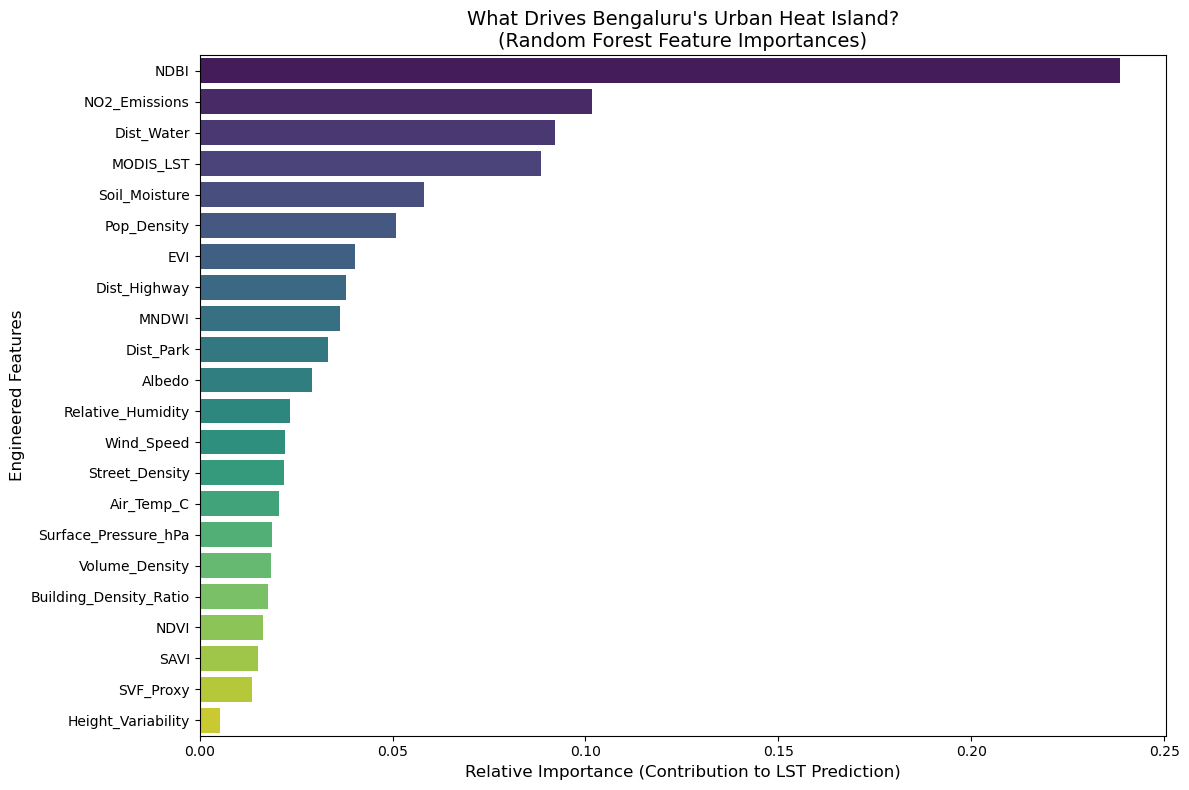

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Loading the final 25-feature dataset...")
df = pd.read_csv('final_25_feature_dataset.csv')

# 1. Feature Preprocessing & KNN Imputation
print("Imputing missing data using K-Nearest Neighbors...")
# We separate the target variable (LST) before imputing so we don't cheat!
y_raw = df['LST']
X_raw = df.drop(columns=['LST'])

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# 2. Creating the Spatial Train/Test Split
print("Executing Spatial Block Cross-Validation...")
# Cluster the map into 5 geographic zones based purely on Latitude & Longitude
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
X_imputed['Spatial_Zone'] = kmeans.fit_predict(X_imputed[['Longitude', 'Latitude']])

# Train on Zones 0, 1, 2, 3. Test on unseen Zone 4.
train_mask = X_imputed['Spatial_Zone'] != 4
test_mask = X_imputed['Spatial_Zone'] == 4

# Drop the Spatial_Zone and Coordinates from the training data so the model doesn't just memorize locations
features_to_drop = ['Spatial_Zone', 'Longitude', 'Latitude']
X_train = X_imputed[train_mask].drop(columns=features_to_drop)
y_train = y_raw[train_mask]
X_test = X_imputed[test_mask].drop(columns=features_to_drop)
y_test = y_raw[test_mask]

# 3. Train the Random Forest Algorithm
print("Training the Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Calculate Usability Metrics
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\n--- MODEL RESULTS ---")
print(f"Test RMSE: {rmse:.2f} °C (Average error in prediction)")
print(f"Test R-Squared: {r2:.2f} (Variance explained by our features)")

# 4. Extract and Visualize Feature Importances (For your presentation!)
importances = rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('What Drives Bengaluru\'s Urban Heat Island?\n(Random Forest Feature Importances)', fontsize=14)
plt.xlabel('Relative Importance (Contribution to LST Prediction)', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Save the cleanly imputed dataset for the future
df_final_clean = X_imputed.drop(columns=['Spatial_Zone'])
df_final_clean['LST'] = y_raw
df_final_clean.to_csv('bengaluru_fully_preprocessed_ready_for_ML.csv', index=False)